#Part 1 - Data Import

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

In [3]:
file_path = 'tender_fix.xlsx'

df = pd.read_excel(file_path)

c:\Users\vasky\AppData\Local\Programs\Python\Python310\lib\site-packages\openpyxl\worksheet\_reader.py:223: UserWarning: Cell J1660 is marked as a date but the serial value 7350571.0 is outside the limits for dates. The cell will be treated as an error.
  warn(msg)


In [4]:
print("5 Baris Pertama Raw Data")
display(df.head())

print("\nInfo Raw Data:")
df.info()

print("\nJumlah data null di setiap kolom:")
df.isnull().sum()

5 Baris Pertama Raw Data


,No.,No. Penawaran,Perusahaan,Contact Person,No. Tlp.,Email,Nama Kapal/UNIT,Pekerjaan,Kategori,Tgl. Penawaran,Tgl. Approval,Harga,Harga Sebelum Approval,Keterangan,TGL
0,1,B.02780/PL.102/BPC/KI-22,PT. Pelabuhan Samudera Palaran,Bpk. Denny,85250954227,denny.rahman2samudera.id,-,Surat penawaran harga Instalasi\nPenyalur Peti...,2022-12-31 00:00:00,NaN,NaN,"Rp 56,000,000",NaN,NaN,2023-01-01
1,2,B.00002/PL.102/BPC/KI-23,PT. Logindo Samudra makmur,Ibu Eka Cristya,82194720182,oprdok_bppn@Logindo.com,-,Surat penawaran harga Sewa\nWater bag,NaN,2023-01-02 00:00:00,2023-01-03 00:00:00,"Rp 3,500,000",Rp. 2.500.000,NaN,2023-01-01
2,3,B.00008/PL.102/BPC/KI-23,PT. Prasida Arta Begja Kamayangan,Ibu. Valida,-,adm.pabk2gmail.com,-,penawaran harga Sertifikasi\nAnnual alat mobil...,NaN,2023-01-03 00:00:00,NaN,"Rp 17,500,000",NaN,NaN,2023-01-01
3,4,B.00009/PL.102/BPC/KI-23,PT. Cipta Bangun Nusantara,Bpk. Yahya,-,yahya.siregar@cbn-epcm.com,-,Surat Penawaran harga witness\npneumatic leak ...,NaN,2023-01-04 00:00:00,NaN,"Rp 50,000,000",NaN,NaN,2023-01-01
4,5,B.02723/PL.102/BPC/KI-23,PT. Pusat Sarana Baruna,Bpk. Basuki Wibawa,81280349639,Basuki.wibawa@interport.co.id,-,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,NaN,2023-01-04 00:00:00,NaN,"Rp 120,000,000",NaN,NaN,2023-01-01



Info Raw Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2430 entries, 0 to 2429
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2430 non-null   int64         
 1   No. Penawaran           2286 non-null   object        
 2   Perusahaan              2403 non-null   object        
 3   Contact Person          2201 non-null   object        
 4   No. Tlp.                1751 non-null   object        
 5   Email                   2053 non-null   object        
 6   Nama Kapal/UNIT         458 non-null    object        
 7   Pekerjaan               2396 non-null   object        
 8   Kategori                707 non-null    object        
 9   Tgl. Penawaran          2392 non-null   object        
 10  Tgl. Approval           599 non-null    object        
 11  Harga                   2394 non-null   object        
 12  Harga Sebelum Approval  573 non-

No.                          0
No. Penawaran              144
Perusahaan                  27
Contact Person             229
No. Tlp.                   679
Email                      377
Nama Kapal/UNIT           1972
Pekerjaan                   34
Kategori                  1723
Tgl. Penawaran              38
Tgl. Approval             1831
Harga                       36
Harga Sebelum Approval    1857
Keterangan                2092
TGL                          0
dtype: int64

# Part 2 - Data Cleaning

## Menghapus Missing Value

In [5]:
df_clean1 = df.drop(columns=['No. Penawaran', 'Contact Person', 'No. Tlp.', 'Email'], errors='ignore')

In [6]:
df_clean1 = df_clean1.dropna(subset=['Perusahaan', 'Harga'])

In [7]:
df_clean1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2379 entries, 0 to 2429
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2379 non-null   int64         
 1   Perusahaan              2379 non-null   object        
 2   Nama Kapal/UNIT         454 non-null    object        
 3   Pekerjaan               2373 non-null   object        
 4   Kategori                701 non-null    object        
 5   Tgl. Penawaran          2361 non-null   object        
 6   Tgl. Approval           594 non-null    object        
 7   Harga                   2379 non-null   object        
 8   Harga Sebelum Approval  564 non-null    object        
 9   Keterangan              327 non-null    object        
 10  TGL                     2379 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 223.0+ KB


## Pembersihan Format Harga

In [8]:
import re
import pandas as pd
import numpy as np

def clean_harga_final(nilai):
    if pd.isna(nilai):
        return np.nan

    teks = str(nilai).strip()

    # Attempt direct conversion to float first, handles scientific notation naturally
    try:
        return float(teks)
    except ValueError:
        pass # If direct conversion fails, proceed with more complex cleaning

    # If it's not a straightforward float string, then clean it

    # 1. Remove currency symbols and leading/trailing spaces
    teks = teks.replace('Rp', '').replace('IDR', '').strip()

    # 2. Heuristic for thousands vs decimal separator:
    # If a comma appears at the end followed by 1 or 2 digits, it's likely a decimal comma.
    # Otherwise, assume period and comma are thousands separators.
    if re.search(r',\d{1,2}$', teks) and not re.search(r'\.', teks):
        # Case: comma is decimal separator (e.g., '123.456,78')
        teks = teks.replace('.', '') # Remove thousands periods
        teks = teks.replace(',', '.') # Replace decimal comma with period
    else:
        # Assume period and comma are thousands separators, or it's an integer
        teks = teks.replace('.', '').replace(',', '')

    # After cleaning, attempt conversion again
    try:
        return float(teks)
    except ValueError:
        return np.nan # If still cannot convert, return NaN

# Buat df_clean2 sebagai salinan dari df_clean1
df_clean2 = df_clean1.copy()

# Terapkan ke dataset df_clean2
for col in ['Harga', 'Harga Sebelum Approval']:
    if col in df_clean2.columns:
        df_clean2[col] = df_clean2[col].apply(clean_harga_final)

# Cek hasil
print("=== Pengecekan Hasil Cleaning Harga pada df_clean2 ===")
# Set display option to prevent scientific notation for floats
pd.options.display.float_format = '{:.0f}'.format
display(df_clean2[['Harga', 'Harga Sebelum Approval']].head())
# Reset display option to default if needed later (optional)
# pd.reset_option('display.float_format')

=== Pengecekan Hasil Cleaning Harga pada df_clean2 ===


,Harga,Harga Sebelum Approval
0,56000000,NaN
1,3500000,2500000
2,17500000,NaN
3,50000000,NaN
4,120000000,NaN


In [9]:
df_clean2 = df_clean2.dropna(subset=['Harga'])

In [10]:
df_clean2.info()
df_clean2.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2355 entries, 0 to 2429
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2355 non-null   int64         
 1   Perusahaan              2355 non-null   object        
 2   Nama Kapal/UNIT         444 non-null    object        
 3   Pekerjaan               2349 non-null   object        
 4   Kategori                692 non-null    object        
 5   Tgl. Penawaran          2337 non-null   object        
 6   Tgl. Approval           581 non-null    object        
 7   Harga                   2355 non-null   float64       
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
 10  TGL                     2355 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1), object(7)
memory usage: 220.8+ KB


,No.,Perusahaan,Nama Kapal/UNIT,Pekerjaan,Kategori,Tgl. Penawaran,Tgl. Approval,Harga,Harga Sebelum Approval,Keterangan,TGL
0,1,PT. Pelabuhan Samudera Palaran,-,Surat penawaran harga Instalasi\nPenyalur Peti...,2022-12-31 00:00:00,NaN,NaN,56000000,NaN,NaN,2023-01-01
1,2,PT. Logindo Samudra makmur,-,Surat penawaran harga Sewa\nWater bag,NaN,2023-01-02 00:00:00,2023-01-03 00:00:00,3500000,2500000,NaN,2023-01-01
2,3,PT. Prasida Arta Begja Kamayangan,-,penawaran harga Sertifikasi\nAnnual alat mobil...,NaN,2023-01-03 00:00:00,NaN,17500000,NaN,NaN,2023-01-01
3,4,PT. Cipta Bangun Nusantara,-,Surat Penawaran harga witness\npneumatic leak ...,NaN,2023-01-04 00:00:00,NaN,50000000,NaN,NaN,2023-01-01
4,5,PT. Pusat Sarana Baruna,-,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,NaN,2023-01-04 00:00:00,NaN,120000000,NaN,NaN,2023-01-01


## Pembersihan Format Tanggal

In [11]:
df_clean3 = df_clean2.drop(columns=['TGL'], errors='ignore')

kolom_tanggal = ['Tgl. Penawaran', 'Tgl. Approval']

for col in kolom_tanggal:
    if col in df_clean3.columns:
        # Konversi kolom di df_clean3 ke tipe datetime Python (teks yang gagal dikonversi menjadi NaT/Not a Time)
        df_clean3[col] = pd.to_datetime(df_clean3[col], errors='coerce')

        # Buang elemen waktu (00:00:00) agar menyisakan format YYYY-MM-DD
        # Pastikan kolom sudah bertipe datetime sebelum menggunakan .dt
        df_clean3[col] = df_clean3[col].dt.normalize()

In [12]:
df_clean3.head()

,No.,Perusahaan,Nama Kapal/UNIT,Pekerjaan,Kategori,Tgl. Penawaran,Tgl. Approval,Harga,Harga Sebelum Approval,Keterangan
0,1,PT. Pelabuhan Samudera Palaran,-,Surat penawaran harga Instalasi\nPenyalur Peti...,2022-12-31 00:00:00,NaT,NaT,56000000,NaN,NaN
1,2,PT. Logindo Samudra makmur,-,Surat penawaran harga Sewa\nWater bag,NaN,2023-01-02,2023-01-03,3500000,2500000,NaN
2,3,PT. Prasida Arta Begja Kamayangan,-,penawaran harga Sertifikasi\nAnnual alat mobil...,NaN,2023-01-03,NaT,17500000,NaN,NaN
3,4,PT. Cipta Bangun Nusantara,-,Surat Penawaran harga witness\npneumatic leak ...,NaN,2023-01-04,NaT,50000000,NaN,NaN
4,5,PT. Pusat Sarana Baruna,-,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,NaN,2023-01-04,NaT,120000000,NaN,NaN


## Membersihkan Missing Value & Duplicate Lainnya

In [13]:
df_clean3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2355 entries, 0 to 2429
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2355 non-null   int64         
 1   Perusahaan              2355 non-null   object        
 2   Nama Kapal/UNIT         444 non-null    object        
 3   Pekerjaan               2349 non-null   object        
 4   Kategori                692 non-null    object        
 5   Tgl. Penawaran          2315 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2355 non-null   float64       
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 202.4+ KB


Kolom Pekerjaan

In [14]:
df_clean4 = df_clean3.dropna(subset=['Pekerjaan'])

In [15]:
df_clean4.loc[:, 'Pekerjaan'] = df_clean4['Pekerjaan'].str.replace('\n', ' ', regex=False).str.strip()

print("5 Baris Pertama DataFrame setelah membersihkan newline di kolom Pekerjaan:")
display(df_clean4.head())

5 Baris Pertama DataFrame setelah membersihkan newline di kolom Pekerjaan:


,No.,Perusahaan,Nama Kapal/UNIT,Pekerjaan,Kategori,Tgl. Penawaran,Tgl. Approval,Harga,Harga Sebelum Approval,Keterangan
0,1,PT. Pelabuhan Samudera Palaran,-,Surat penawaran harga Instalasi Penyalur Petir...,2022-12-31 00:00:00,NaT,NaT,56000000,NaN,NaN
1,2,PT. Logindo Samudra makmur,-,Surat penawaran harga Sewa Water bag,NaN,2023-01-02,2023-01-03,3500000,2500000,NaN
2,3,PT. Prasida Arta Begja Kamayangan,-,penawaran harga Sertifikasi Annual alat mobile...,NaN,2023-01-03,NaT,17500000,NaN,NaN
3,4,PT. Cipta Bangun Nusantara,-,Surat Penawaran harga witness pneumatic leak t...,NaN,2023-01-04,NaT,50000000,NaN,NaN
4,5,PT. Pusat Sarana Baruna,-,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,NaN,2023-01-04,NaT,120000000,NaN,NaN


In [16]:
df_clean4.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2349 entries, 0 to 2429
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2349 non-null   int64         
 1   Perusahaan              2349 non-null   object        
 2   Nama Kapal/UNIT         444 non-null    object        
 3   Pekerjaan               2349 non-null   object        
 4   Kategori                691 non-null    object        
 5   Tgl. Penawaran          2309 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2349 non-null   float64       
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 201.9+ KB


# Part 3 - Feature Engineering

## Date time extraction -> Year, Quarter, Month

In [17]:
df_clean4.loc[:, 'Year'] = df_clean4['Tgl. Penawaran'].dt.year
df_clean4.loc[:, 'Quarter'] = df_clean4['Tgl. Penawaran'].dt.quarter
df_clean4.loc[:, 'Month'] = df_clean4['Tgl. Penawaran'].dt.month

display(df_clean4[['Tgl. Penawaran', 'Year', 'Quarter', 'Month']].head())
display(df_clean4[['Tgl. Penawaran', 'Year', 'Quarter', 'Month']].tail())

df_clean4.info()

C:\Users\vasky\AppData\Local\Temp\ipykernel_36416\1470560512.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean4.loc[:, 'Year'] = df_clean4['Tgl. Penawaran'].dt.year
C:\Users\vasky\AppData\Local\Temp\ipykernel_36416\1470560512.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean4.loc[:, 'Quarter'] = df_clean4['Tgl. Penawaran'].dt.quarter
C:\Users\vasky\AppData\Local\Temp\ipykernel_36416\1470560512.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

,Tgl. Penawaran,Year,Quarter,Month
0,NaT,NaN,NaN,NaN
1,2023-01-02,2023,1,1
2,2023-01-03,2023,1,1
3,2023-01-04,2023,1,1
4,2023-01-04,2023,1,1


,Tgl. Penawaran,Year,Quarter,Month
2425,2025-11-20,2025,4,11
2426,2025-11-26,2025,4,11
2427,2025-11-27,2025,4,11
2428,2025-11-01,2025,4,11
2429,2025-11-28,2025,4,11


<class 'pandas.core.frame.DataFrame'>
Index: 2349 entries, 0 to 2429
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2349 non-null   int64         
 1   Perusahaan              2349 non-null   object        
 2   Nama Kapal/UNIT         444 non-null    object        
 3   Pekerjaan               2349 non-null   object        
 4   Kategori                691 non-null    object        
 5   Tgl. Penawaran          2309 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2349 non-null   float64       
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
 10  Year                    2309 non-null   float64       
 11  Quarter                 2309 non-null   float64       
 12  Month                   2309 non-null   float64      

## Win/Lose

In [19]:
df_clean4.loc[:, 'Win/Lose'] = np.where(df_clean4['Harga Sebelum Approval'].notna(), 1, 0)
df_clean4.loc[:, 'Win/Lose'] = df_clean4['Win/Lose'].astype(int)

print("5 Baris Pertama DataFrame dengan kolom 'Win/Lose' baru:")
display(df_clean4[['Harga Sebelum Approval', 'Win/Lose']].head())

print("\nInfo DataFrame setelah penambahan kolom 'Win/Lose':")
df_clean4.info()

5 Baris Pertama DataFrame dengan kolom 'Win/Lose' baru:


,Harga Sebelum Approval,Win/Lose
0,NaN,0
1,2500000,1
2,NaN,0
3,NaN,0
4,NaN,0



Info DataFrame setelah penambahan kolom 'Win/Lose':
<class 'pandas.core.frame.DataFrame'>
Index: 2349 entries, 0 to 2429
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2349 non-null   int64         
 1   Perusahaan              2349 non-null   object        
 2   Nama Kapal/UNIT         444 non-null    object        
 3   Pekerjaan               2349 non-null   object        
 4   Kategori                691 non-null    object        
 5   Tgl. Penawaran          2309 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2349 non-null   float64       
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
 10  Year                    2309 non-null   float64       
 11  Quarter                 2309 non-null   float64       
 12  

## Type of Client

In [20]:
df_clean5 = df_clean4.copy()
print("df_clean5 berhasil dibuat sebagai salinan dari df_clean4.")
display(df_clean5.head())

df_clean5 berhasil dibuat sebagai salinan dari df_clean4.


,No.,Perusahaan,Nama Kapal/UNIT,Pekerjaan,Kategori,Tgl. Penawaran,Tgl. Approval,Harga,Harga Sebelum Approval,Keterangan,Year,Quarter,Month,Win/Lose
0,1,PT. Pelabuhan Samudera Palaran,-,Surat penawaran harga Instalasi Penyalur Petir...,2022-12-31 00:00:00,NaT,NaT,56000000,NaN,NaN,NaN,NaN,NaN,0
1,2,PT. Logindo Samudra makmur,-,Surat penawaran harga Sewa Water bag,NaN,2023-01-02,2023-01-03,3500000,2500000,NaN,2023,1,1,1
2,3,PT. Prasida Arta Begja Kamayangan,-,penawaran harga Sertifikasi Annual alat mobile...,NaN,2023-01-03,NaT,17500000,NaN,NaN,2023,1,1,0
3,4,PT. Cipta Bangun Nusantara,-,Surat Penawaran harga witness pneumatic leak t...,NaN,2023-01-04,NaT,50000000,NaN,NaN,2023,1,1,0
4,5,PT. Pusat Sarana Baruna,-,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,NaN,2023-01-04,NaT,120000000,NaN,NaN,2023,1,1,0


### Opsional: Unduh df_clean5 sebagai file Excel

1. Ekstrak Klien Unik & Export ke Excel

In [21]:
import pandas as pd
import os

# Pastikan file ini ada di folder yang sama dengan notebook
input_filename = 'tender_data_cleaned_2.xlsx'

if os.path.exists(input_filename):
    df_source = pd.read_excel(input_filename)
    
    # Proses data
    df_client = df_source['Perusahaan'].value_counts().reset_index()
    df_client.columns = ['Perusahaan', 'Jumlah Tender']
    df_client['Type of Client'] = ''

    # Simpan hasil
    nama_file_output = 'Mapping_Client_BKI.xlsx'
    df_client.to_excel(nama_file_output, index=False)
    print(f"Selesai! File disimpan sebagai: {os.path.abspath(nama_file_output)}")
else:
    print(f"Error: File '{input_filename}' tidak ditemukan di {os.getcwd()}")

Selesai! File disimpan sebagai: c:\Users\vasky\Downloads\TA_Vaskya\Mapping_Client_BKI.xlsx


2. Mapping Manual di Excel (Hukum Pareto)

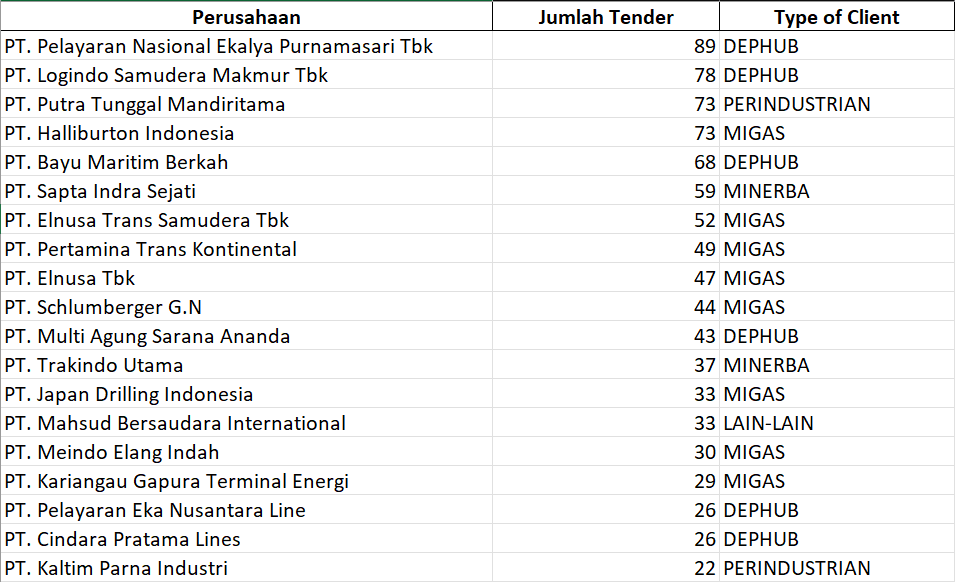

3. Upload Kembali ke Google Colab dan Merge Data

In [23]:
df_clean6 = pd.read_excel('tender_data_cleaned_2.xlsx')
print("Info df_clean6:")
df_clean6.info()

Info df_clean6:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2348 non-null   int64         
 1   Perusahaan              2348 non-null   object        
 2   Nama Kapal/UNIT         443 non-null    object        
 3   Pekerjaan               2348 non-null   object        
 4   Kategori                691 non-null    object        
 5   Tgl. Penawaran          2308 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2348 non-null   int64         
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
 10  Year                    2308 non-null   float64       
 11  Quarter                 2308 non-null   float64       
 12  Month                   2308 non

In [25]:
# 1. Load data master yang sudah dimapped
master_file_path = 'Mapping_Client_BKI_Fix.xlsx'
df_master_client = pd.read_excel(master_file_path)

# Pastikan kolom 'Client' dan 'Type of Client (Pasar)' ada di df_master_client
# Sesuaikan nama kolom jika berbeda di file Excel Anda

# 2. Konversi Master ke Dictionary agar proses pencarian cepat
# Kita buat semua keyword perusahaan di master menjadi lowercase untuk pencarian yang tidak case-sensitive
master_client_dict = dict(zip(df_master_client['Perusahaan'].str.lower(), df_master_client['Type of Client']))

def mapping_type_of_client(nama_perusahaan):
    if pd.isna(nama_perusahaan):
        return np.nan # Mengembalikan np.nan jika input null

    nama_clean = str(nama_perusahaan).lower()

    # Cari kecocokan eksak terlebih dahulu
    if nama_clean in master_client_dict:
        return master_client_dict[nama_clean]

    # Jika tidak ada kecocokan eksak, cari keyword yang terkandung dalam nama perusahaan
    # Ini bisa disesuaikan lebih lanjut jika ada pola tertentu
    for keyword, client_type in master_client_dict.items():
        if keyword in nama_clean:
            return client_type

    return np.nan # Mengembalikan np.nan jika tidak ada yang cocok

# 3. Eksekusi mapping ke kolom baru 'Type of Client' di df_clean6 (sesuai permintaan user)
df_clean6.loc[:, 'Type of Client'] = df_clean6['Perusahaan'].apply(mapping_type_of_client)

print("5 Baris Pertama DataFrame df_clean6 dengan kolom 'Type of Client' baru:")
display(df_clean6[['Perusahaan', 'Type of Client']].head())

print("\nInfo DataFrame df_clean6 setelah penambahan kolom 'Type of Client':")
df_clean6.info()

5 Baris Pertama DataFrame df_clean6 dengan kolom 'Type of Client' baru:


,Perusahaan,Type of Client
0,PT. Pelabuhan Samudera Palaran,DEPHUB
1,PT. Logindo Samudera Makmur Tbk,DEPHUB
2,PT. Prasida Arta Begja Kamayangan,LAIN-LAIN
3,PT. Cipta Bangun Nusantara,LAIN-LAIN
4,PT. Pusat Sarana Baruna,DEPHUB



Info DataFrame df_clean6 setelah penambahan kolom 'Type of Client':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2348 non-null   int64         
 1   Perusahaan              2348 non-null   object        
 2   Nama Kapal/UNIT         443 non-null    object        
 3   Pekerjaan               2348 non-null   object        
 4   Kategori                691 non-null    object        
 5   Tgl. Penawaran          2308 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2348 non-null   int64         
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
 10  Year                    2308 non-null   float64       
 11  Quarter                 2308 non-null  

## Type of Project

In [26]:
category_rules = {
    # 1. KATEGORI SPESIFIK & LAB (Taruh paling atas)
    'Pengujian Laboratorium': ['laboratorium', 'lab test', 'uji lab', 'analysis lab'],
    'Labor Survey': ['labor survey', 'pengerahan tenaga', 'supply personil'],
    'Survey/Identifikasi/Inventarisasi': ['survey', 'identifikasi', 'inventarisasi', 'pendataan', 'mapping'],
    'Pemetaan': ['pemetaan', 'bathymetry', 'topografi', 'gis'],

    # 2. INSPEKSI & SERTIFIKASI (Diperkaya dengan objek: Tangki, Kapal, Alat Angkat)
    'Inspeksi': [
        'inspeksi', 'inspection', 'pemeriksaan', 'ndt', 'underwater', 'annual',
        'tanki', 'tank', 'vessel', 'ut', # Objek Tangki
        'crane', 'lifting', 'gear', 'wire', 'hoist', # Objek Alat Angkat (Riksa Uji)
        'kapal', 'marine', 'tug', 'cst' # Objek Kelautan / Marine Survey
    ],
    'Sertifikasi': ['sertifikasi', 'certification', 're-sertifikasi', 'sertifikat', 'migas', 'riksa uji', 'plo', 'coi', 'certificate', 'slo', 'slf'],

    # 3. PENGUJIAN (Diperkaya dengan Kalibrasi & Uji Kapal)
    'Pengujian': [
        'pengujian', 'testing', 'commissioning', 'load test', 'test',
        'kalibrasi', 'calibration', 'tera', # Kalibrasi alat ukur
        'bollard', 'pull', 'fuel', 'consumption', 'fct', 'psv' # Uji performa kapal
    ],

    # 4. ASSESSMENT & AUDIT
    'Assessment': ['assessment', 'kajian', 'studi kelayakan', 'evaluasi teknis'],
    'Audit': ['audit', 'verifikasi', 'penelaahan', 'rla'],

    # 5. SUPERVISI & KONSULTANSI
    'Monitoring': ['monitoring', 'pemantauan', 'pengawasan berkala'],
    'Supervisi': ['supervisi', 'supervision', 'pengawasan konstruksi'],
    'Konsultansi': ['konsultansi', 'consultancy', 'advisory', 'jasa konsultansi'],

    # 6. LAINNYA
    'Training': ['training', 'pelatihan', 'workshop', 'sosialisasi']
}

def classify_project(text):
    if pd.isna(text):
        return "LAIN-LAIN"

    text_clean = str(text).lower()

    # Looping berdasarkan rule yang dibuat
    for category, keywords in category_rules.items():
        for word in keywords:
            if word in text_clean:
                return category

    return "LAIN-LAIN"

df_clean6.loc[:, 'Type of Project'] = df_clean6['Pekerjaan'].apply(classify_project)

print("5 Baris Pertama DataFrame df_clean6 dengan kolom 'Type of Project' baru:")
display(df_clean6[['Pekerjaan', 'Type of Project']].head())

print("\nInfo DataFrame df_clean6 setelah penambahan kolom 'Type of Project':")
df_clean6.info()

5 Baris Pertama DataFrame df_clean6 dengan kolom 'Type of Project' baru:


,Pekerjaan,Type of Project
0,Surat penawaran harga Instalasi Penyalur Petir...,LAIN-LAIN
1,Surat penawaran harga Sewa Water bag,LAIN-LAIN
2,penawaran harga Sertifikasi Annual alat mobile...,Inspeksi
3,Surat Penawaran harga witness pneumatic leak t...,Inspeksi
4,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,Inspeksi



Info DataFrame df_clean6 setelah penambahan kolom 'Type of Project':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   No.                     2348 non-null   int64         
 1   Perusahaan              2348 non-null   object        
 2   Nama Kapal/UNIT         443 non-null    object        
 3   Pekerjaan               2348 non-null   object        
 4   Kategori                691 non-null    object        
 5   Tgl. Penawaran          2308 non-null   datetime64[ns]
 6   Tgl. Approval           538 non-null    datetime64[ns]
 7   Harga                   2348 non-null   int64         
 8   Harga Sebelum Approval  525 non-null    float64       
 9   Keterangan              318 non-null    object        
 10  Year                    2308 non-null   float64       
 11  Quarter                 2308 non-null 

In [28]:
# Nama file output
output_filename = 'type_of_project.xlsx'

# Simpan ke Excel (otomatis tersimpan di folder yang sama dengan notebook/script)
df_clean6.to_excel(output_filename, index=False)

# Di VS Code, file sudah ada di harddisk, jadi tidak perlu fungsi download
print(f"File '{output_filename}' berhasil disimpan di folder project.")

File 'type_of_project.xlsx' berhasil disimpan di folder project.


## Exploratory Data Analysis (EDA)
Analisis hubungan variabel terhadap Harga Tender setelah Feature Engineering.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid')

# Memastikan df_clean6 digunakan untuk EDA
df_eda = df_clean6.copy()
df_eda['Harga_log'] = np.log1p(df_eda['Harga'])


### 1. Harga vs Type of Client

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_eda, x='Type of Client', y='Harga_log', palette='Set2')
plt.title('Distribusi Harga (Log) per Type of Client')
plt.xticks(rotation=45, ha='right')
plt.show()

### 2. Harga vs Type of Project

In [ ]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_eda, x='Type of Project', y='Harga_log', palette='Set3')
plt.title('Distribusi Harga (Log) per Type of Project')
plt.xticks(rotation=45, ha='right')
plt.show()

### 3. Harga vs Waktu (Year & Quarter)

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df_eda, x='Year', y='Harga_log', ax=ax[0], palette='Blues')
ax[0].set_title('Harga vs Tahun')

sns.boxplot(data=df_eda, x='Quarter', y='Harga_log', ax=ax[1], palette='Greens')
ax[1].set_title('Harga vs Kuartal')
plt.show()

### 4. Harga vs Win/Lose

In [ ]:
plt.figure(figsize=(6, 5))
sns.violinplot(data=df_eda, x='Win/Lose', y='Harga_log', palette='muted')
plt.title('Distribusi Harga: Kalah (0) vs Menang (1)')
plt.show()

#Part 4 - Standarisasi Data

##Standarisasi Numerik (Log Transform)

Harga tender dan harga pemenang pasti sangat variatif (dari Rp10 juta hingga puluhan miliar). Hal ini membuat data menjadi skewed (condong ke satu sisi) dan rentan terhadap outlier.Metode yang digunakan adalah $log(x+1)$, yang di Python dieksekusi menggunakan np.log1p().

In [29]:
import numpy as np

# Terapkan transformasi log(x+1) ke kolom 'Harga' dan 'Harga Sebelum Approval'
df_clean6.loc[:, 'Harga_log'] = np.log1p(df_clean6['Harga'])
df_clean6.loc[:, 'Harga Sebelum Approval_log'] = np.log1p(df_clean6['Harga Sebelum Approval'])

print("5 Baris Pertama DataFrame dengan kolom harga yang ditransformasi:")
display(df_clean6[['Harga', 'Harga_log', 'Harga Sebelum Approval', 'Harga Sebelum Approval_log']].head())

print("\nInfo DataFrame setelah transformasi log:")
df_clean6.info()

5 Baris Pertama DataFrame dengan kolom harga yang ditransformasi:


,Harga,Harga_log,Harga Sebelum Approval,Harga Sebelum Approval_log
0,56000000,18,NaN,NaN
1,3500000,15,2500000,15
2,17500000,17,NaN,NaN
3,50000000,18,NaN,NaN
4,120000000,19,NaN,NaN



Info DataFrame setelah transformasi log:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 18 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   No.                         2348 non-null   int64         
 1   Perusahaan                  2348 non-null   object        
 2   Nama Kapal/UNIT             443 non-null    object        
 3   Pekerjaan                   2348 non-null   object        
 4   Kategori                    691 non-null    object        
 5   Tgl. Penawaran              2308 non-null   datetime64[ns]
 6   Tgl. Approval               538 non-null    datetime64[ns]
 7   Harga                       2348 non-null   int64         
 8   Harga Sebelum Approval      525 non-null    float64       
 9   Keterangan                  318 non-null    object        
 10  Year                        2308 non-null   float64       
 11  Quarter       

In [30]:
# Hapus kolom 'Harga' dan 'Harga Sebelum Approval' yang belum distandarisasi
df_clean7 = df_clean6.drop(columns=['Harga', 'Harga Sebelum Approval'])

##Standarisasi Kategorikal (Encoding)

Algoritma regresi murni hanya bisa membaca angka. Jadi, kita harus mengubah teks menjadi angka

One-Hot Encoding: Untuk variabel dengan banyak kategori yang tidak memiliki tingkatan (seperti Type of Client dan Type of Project). Ini akan mengubah 1 kolom berisi 9 kategori menjadi 8 kolom baru (0 atau 1) untuk menghindari dummy variable trap.

UBAH JADI INDEKS

In [31]:
# Lakukan One-Hot Encoding pada kolom 'Type of Client' dan 'Type of Project'
df_encoded = pd.get_dummies(df_clean7, columns=['Type of Client', 'Type of Project'], drop_first=True)

print("5 Baris Pertama DataFrame setelah One-Hot Encoding:")
display(df_encoded.head())

print("\nInfo DataFrame setelah One-Hot Encoding:")
df_encoded.info()

5 Baris Pertama DataFrame setelah One-Hot Encoding:


,No.,Perusahaan,Nama Kapal/UNIT,Pekerjaan,Kategori,Tgl. Penawaran,Tgl. Approval,Keterangan,Year,Quarter,...,Type of Project_Inspeksi,Type of Project_Konsultansi,Type of Project_LAIN-LAIN,Type of Project_Pemetaan,Type of Project_Pengujian,Type of Project_Pengujian Laboratorium,Type of Project_Sertifikasi,Type of Project_Supervisi,Type of Project_Survey/Identifikasi/Inventarisasi,Type of Project_Training
0,1,PT. Pelabuhan Samudera Palaran,-,Surat penawaran harga Instalasi Penyalur Petir...,2022-12-31 00:00:00,NaT,NaT,NaN,NaN,NaN,...,False,False,True,False,False,False,False,False,False,False
1,2,PT. Logindo Samudera Makmur Tbk,-,Surat penawaran harga Sewa Water bag,NaN,2023-01-02,2023-01-03,NaN,2023,1,...,False,False,True,False,False,False,False,False,False,False
2,3,PT. Prasida Arta Begja Kamayangan,-,penawaran harga Sertifikasi Annual alat mobile...,NaN,2023-01-03,NaT,NaN,2023,1,...,True,False,False,False,False,False,False,False,False,False
3,4,PT. Cipta Bangun Nusantara,-,Surat Penawaran harga witness pneumatic leak t...,NaN,2023-01-04,NaT,NaN,2023,1,...,True,False,False,False,False,False,False,False,False,False
4,5,PT. Pusat Sarana Baruna,-,Penawaran Harga Tera Tank – Bio Diesel /B.30(T...,NaN,2023-01-04,NaT,NaN,2023,1,...,True,False,False,False,False,False,False,False,False,False



Info DataFrame setelah One-Hot Encoding:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2348 entries, 0 to 2347
Data columns (total 31 columns):
 #   Column                                             Non-Null Count  Dtype         
---  ------                                             --------------  -----         
 0   No.                                                2348 non-null   int64         
 1   Perusahaan                                         2348 non-null   object        
 2   Nama Kapal/UNIT                                    443 non-null    object        
 3   Pekerjaan                                          2348 non-null   object        
 4   Kategori                                           691 non-null    object        
 5   Tgl. Penawaran                                     2308 non-null   datetime64[ns]
 6   Tgl. Approval                                      538 non-null    datetime64[ns]
 7   Keterangan                                         318 non-null

#Part 4 - Pembangunan Model

## Data Partitioning

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
import numpy as np

# 1. Buang kolom yang tidak diperlukan & informasi masa depan
df_model = df_encoded.drop(columns=[
    'No.', 'Perusahaan', 'Nama Kapal/UNIT', 'Pekerjaan', 'Kategori',
    'Tgl. Penawaran', 'Tgl. Approval', 'Keterangan', 'Win/Lose'
])

# 2. PERBAIKAN: Sapu bersih semua baris yang mengandung NaN
df_model = df_model.dropna()

# 3. Definisikan Target (y) dan Fitur (X)
y = df_model['Harga Sebelum Approval_log']
X = df_model.drop(columns=['Harga Sebelum Approval_log'])

# Ubah kolom boolean menjadi integer (1/0)
for col in X.select_dtypes(include=['bool']).columns:
    X[col] = X[col].astype(int)

# 4. Data Partitioning (80% Latih, 20% Uji)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- STRATEGI BARU: OUTLIER REMOVAL PADA TRAINING SET ---
# Kita hitung selisih antara tebakan awal (Harga_log) dengan Harga Sebelum Approval_log
diff = y_train - X_train['Harga_log']
Q1 = diff.quantile(0.25)
Q3 = diff.quantile(0.75)
IQR = Q3 - Q1
mask = (diff >= Q1 - 1.5 * IQR) & (diff <= Q3 + 1.5 * IQR)

X_train_clean = X_train[mask]
y_train_clean = y_train[mask]
print(f"Data siap: {X_train_clean.shape[0]} baris latih (setelah outlier dibuang), {X_test.shape[0]} baris ujian.")

# 5. Inisialisasi dan Pelatihan Model (MENGGUNAKAN RIDGE REGRESSION)
model_lr = Ridge(alpha=1.0)
model_lr.fit(X_train_clean, y_train_clean)
print("Model Ridge Regression (sebagai pengganti LR standar) selesai dilatih!")

# 6. Melakukan Prediksi pada data ujian
y_pred_lr = model_lr.predict(X_test)
print("Prediksi harga pada data testing selesai!")

Data siap: 415 baris untuk latihan, 104 baris untuk ujian.
Model Linear Regression selesai dilatih!
Prediksi harga pada data testing selesai!


## Inisialisasi Model

### Linear Regression

In [33]:
from sklearn.linear_model import Ridge

# Inisialisasi model Ridge Regression
model_lr = Ridge(alpha=1.0)

In [34]:
from sklearn.linear_model import Ridge

model_lr = Ridge(alpha=1.0)

model_lr.fit(X_train_clean, y_train_clean)

print("Model Ridge Regression selesai dilatih!")

Model Linear Regression selesai dilatih!


In [35]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Kembalikan nilai ke skala aslinya (Rupiah) menggunakan kebalikan log1p
y_test_asli = np.expm1(y_test)
y_pred_lr_asli = np.expm1(y_pred_lr)

# 2. Hitung error menggunakan nilai aslinya
mae_lr = mean_absolute_error(y_test_asli, y_pred_lr_asli)
rmse_lr = np.sqrt(mean_squared_error(y_test_asli, y_pred_lr_asli))
mape_lr = mean_absolute_percentage_error(y_test_asli, y_pred_lr_asli)

# Menampilkan hasil
print("=== Evaluasi Model Linear Regression (Skala Rupiah) ===")
print(f"MAE  : Rp {mae_lr:,.2f}")
print(f"RMSE : Rp {rmse_lr:,.2f}")
print(f"MAPE : {mape_lr * 100:.2f}%")

=== Evaluasi Model Linear Regression (Skala Rupiah) ===
MAE  : Rp 12,224,894.07
RMSE : Rp 39,655,987.84
MAPE : 29.89%


### Random Forest Regression

In [37]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# 1. Inisialisasi model dasar Random Forest
rf_base = RandomForestRegressor(random_state=42)

# 2. Tentukan 'kemungkinan' parameter yang ingin diuji (Grid Search)
param_grid_rf = {
    'n_estimators': [50, 100, 200],      # Uji dengan 50, 100, dan 200 pohon
    'max_depth': [None, 10, 20],         # Uji seberapa dalam pohon boleh tumbuh
    'min_samples_split': [2, 5, 10]      # Uji syarat jumlah data untuk membuat aturan baru
}

# 3. Siapkan Mesin Pencari (Grid Search + 5-Fold CV)
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    cv=5,                                # 5-Fold Cross Validation
    scoring='neg_mean_absolute_error',   # Cari yang Error MAE-nya paling kecil
    n_jobs=-1                            # Gunakan seluruh inti prosesor agar cepat
)

print("Mulai mencari parameter terbaik dan melatih Random Forest...")
print("(Tunggu sebentar, proses ini akan melatih model ratusan kali)")

# 4. Mulai proses pencarian dan pembelajaran (fit)
grid_search_rf.fit(X_train_clean, y_train_clean)

# Ambil model terbaik hasil pencarian
best_model_rf = grid_search_rf.best_estimator_

print("Pencarian selesai")
print(f"Kombinasi Parameter Terbaik: {grid_search_rf.best_params_}")

Mulai mencari parameter terbaik dan melatih Random Forest...
(Tunggu sebentar, proses ini akan melatih model ratusan kali)
Pencarian selesai
Kombinasi Parameter Terbaik: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 50}


In [38]:
#Algoritma Random Forest
y_pred_rf = best_model_rf.predict(X_test)

y_test_asli = np.expm1(y_test)
y_pred_rf_asli = np.expm1(y_pred_rf)

mae_rf = mean_absolute_error(y_test_asli, y_pred_rf_asli)
rmse_rf = np.sqrt(mean_squared_error(y_test_asli, y_pred_rf_asli))
mape_rf = mean_absolute_percentage_error(y_test_asli, y_pred_rf_asli)

# Menampilkan hasil perbandingan
print("=== Evaluasi Model Random Forest (Skala Rupiah) ===")
print(f"MAE  : Rp {mae_rf:,.2f}")
print(f"RMSE : Rp {rmse_rf:,.2f}")
print(f"MAPE : {mape_rf * 100:.2f}%")

=== Evaluasi Model Random Forest (Skala Rupiah) ===
MAE  : Rp 8,678,848.89
RMSE : Rp 33,583,945.03
MAPE : 29.62%


### Support Vector Regression

In [40]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 1. Membuat Pipeline: Data harus di-Scale dulu (StandardScaler), baru masuk ke SVR
pipeline_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR())
])

# 2. Menentukan parameter SVR yang akan diuji
param_grid_svr = {
    'svr__kernel': ['linear', 'rbf'],     # Uji jalan lurus (linear) vs jalan melengkung (rbf)
    'svr__C': [0.1, 1, 10, 100],          # Toleransi error (Regularization)
    'svr__gamma': ['scale', 'auto']       # Pengaruh satu sampel data
}

# 3. Siapkan Mesin Pencari (Grid Search + 5-Fold CV)
grid_search_svr = GridSearchCV(
    estimator=pipeline_svr,
    param_grid=param_grid_svr,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

print("Mulai proses Scaling, mencari parameter terbaik, dan melatih SVR...")
print("(Ini mungkin memakan waktu agak lama tergantung kerumitan data)")

# 4. Mulai proses pencarian dan pelatihan
grid_search_svr.fit(X_train_clean, y_train_clean)

# Ambil model SVR terbaik
best_model_svr = grid_search_svr.best_estimator_

print("\nPencarian SVR selesai")
print(f"Kombinasi Parameter SVR Terbaik: {grid_search_svr.best_params_}")

Mulai proses Scaling, mencari parameter terbaik, dan melatih SVR...
(Ini mungkin memakan waktu agak lama tergantung kerumitan data)

Pencarian SVR selesai
Kombinasi Parameter SVR Terbaik: {'svr__C': 1, 'svr__gamma': 'scale', 'svr__kernel': 'linear'}


In [41]:
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import numpy as np

# 1. Inisialisasi model SVR dengan parameter terbaik hasil Grid Search
best_svr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR(kernel='linear', C=1, gamma='scale'))
])

# 2. Melatih model menggunakan data training
best_svr_model.fit(X_train_clean, y_train_clean)

# 3. Melakukan prediksi pada data ujian (X_test)
y_pred_svr = best_svr_model.fit(X_train_clean, y_train_clean).predict(X_test)

# 4. Kembalikan tebakan dan kunci jawaban ke skala asli (Rupiah)
y_test_asli = np.expm1(y_test)
y_pred_svr_asli = np.expm1(y_pred_svr)

# 5. Hitung metrik evaluasi (MAE, RMSE, MAPE)
mae_svr = mean_absolute_error(y_test_asli, y_pred_svr_asli)
rmse_svr = np.sqrt(mean_squared_error(y_test_asli, y_pred_svr_asli))
mape_svr = mean_absolute_percentage_error(y_test_asli, y_pred_svr_asli)

# Menampilkan hasil akhir
print("=== Evaluasi Model SVR Terbaik (Skala Rupiah) ===")
print(f"MAE  : Rp {mae_svr:,.2f}")
print(f"RMSE : Rp {rmse_svr:,.2f}")
print(f"MAPE : {mape_svr * 100:.2f}%")

=== Evaluasi Model SVR Terbaik (Skala Rupiah) ===
MAE  : Rp 6,511,134.68
RMSE : Rp 18,016,661.63
MAPE : 19.90%


### Visualisasi Actual vs Predicted (Linear Regression, Random Forest, SVR)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pastikan hasil prediksi sudah dalam bentuk eksponensial (rupiah)
preds = {
    'Linear Regression': np.expm1(model_lr.predict(X_test)),
    'Random Forest': np.expm1(best_model_rf.predict(X_test)),
    'SVR': np.expm1(best_svr_model.predict(X_test))
}

y_test_asli = np.expm1(y_test)

for i, (name, pred) in enumerate(preds.items()):
    axes[i].scatter(y_test_asli, pred, alpha=0.5, color='darkorange')
    axes[i].plot([y_test_asli.min(), y_test_asli.max()], [y_test_asli.min(), y_test_asli.max()], 'k--', lw=2)
    axes[i].set_title(f'Actual vs Predicted: {name}')
    axes[i].set_xlabel('Actual Harga Sebelum Approval (Rp)')
    axes[i].set_ylabel('Predicted Harga Sebelum Approval (Rp)')
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')

plt.tight_layout()
plt.show()